# Tester_branch에서 최종 모델 성능 확인 진행

In [25]:
# 라이브러리 및 데이터 불러오기

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
wine = load_wine()

''' 데이터 코드를 작성해주세요 '''

X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# feature로 사용할 데이터에서는 'target' 컬럼을 drop합니다.
# target은 'target' 컬럼만을 대상으로 합니다.
# X, y 데이터를 test size는 0.2, random_state 값은 42로 하여 train 데이터와 test 데이터로 분할합니다.

# DT 모델링 성능

Decision Tree 최적 하이퍼파라미터: {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 2, 'min_samples_split': 5}
Train CV 기준 정확도: 0.9288177339901479
Test 데이터 정확도: 0.9166666666666666


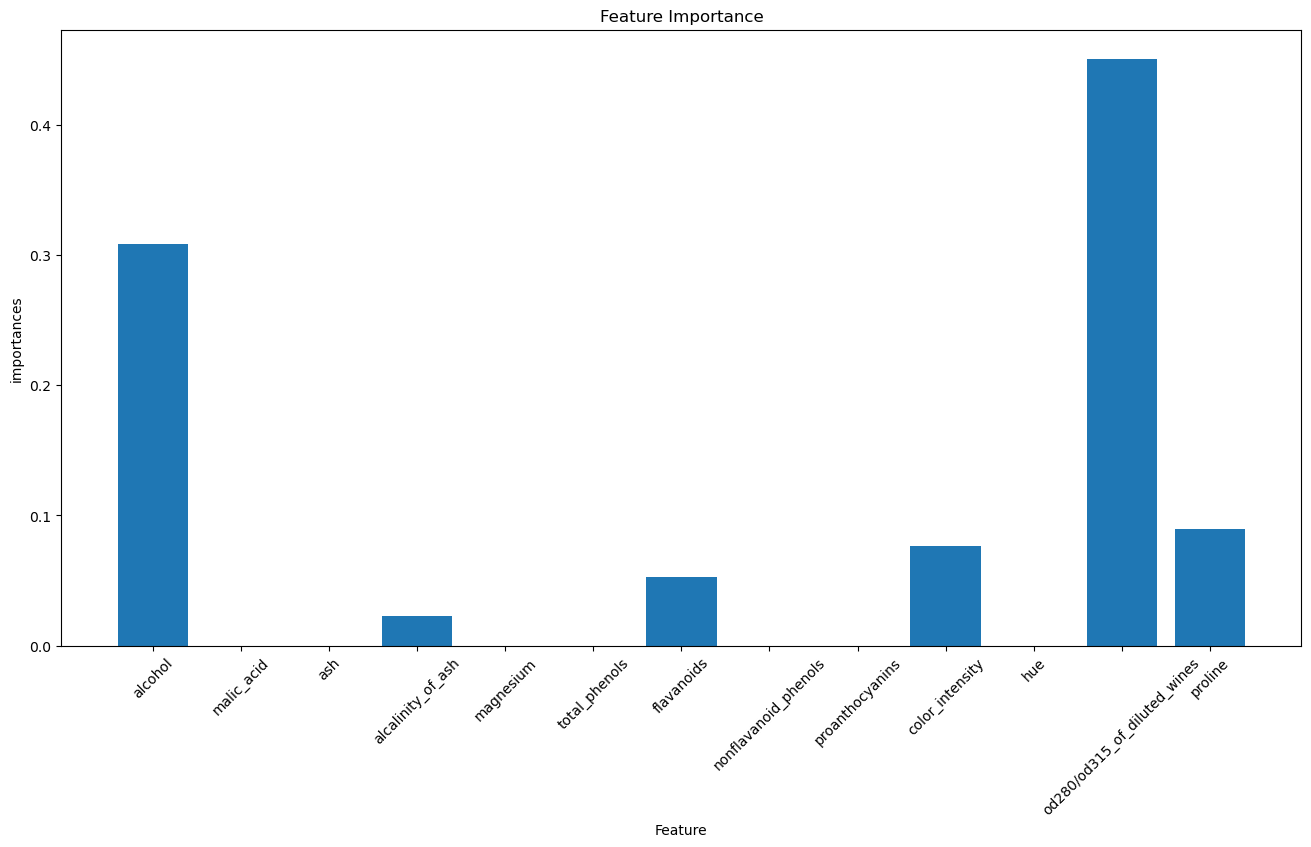

In [26]:
''' 코드를 작성해주세요 '''

param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

dt = DecisionTreeClassifier()


grid_search_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_dt.fit(X_train, y_train)
best_dt = grid_search_dt.best_estimator_

y_pred_dt = best_dt.predict(X_test)
dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree 최적 하이퍼파라미터:", grid_search_dt.best_params_)
print("Train CV 기준 정확도:", grid_search_dt.best_score_)
print("Test 데이터 정확도:", best_dt.score(X_test, y_test))

# Feature Importance 시각화
importances_dt = best_dt.feature_importances_
plt.figure(figsize=(16,8))
plt.bar(X.columns, importances_dt)
plt.xlabel("Feature")
plt.ylabel("importances")
plt.title("Feature Importance")
plt.xticks(rotation = 45)
plt.show()

# XGB 모델링 성능

XGBoost 최적 하이퍼파라미터: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Train CV 기준 정확도: 0.9504926108374384
Test 데이터 정확도: 0.9722222222222222


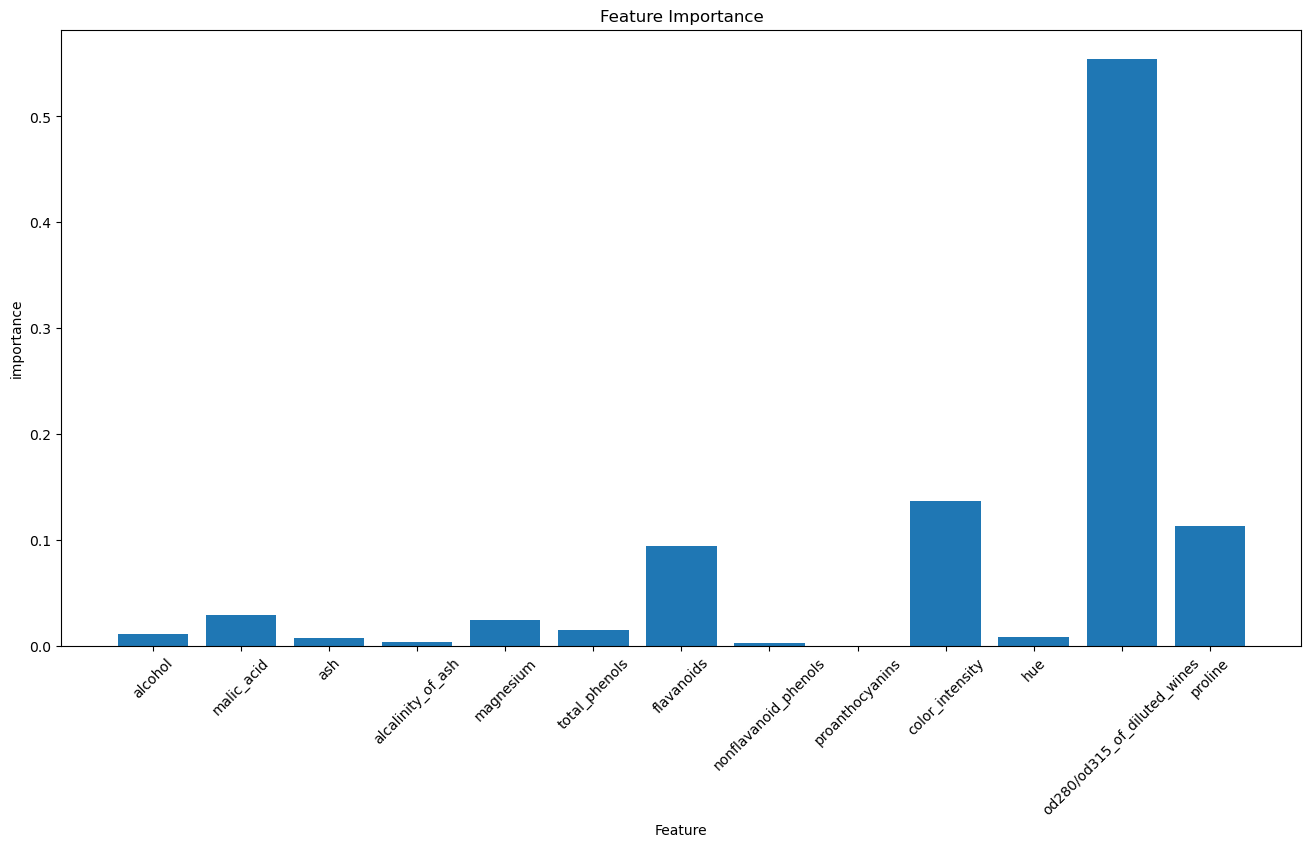

In [32]:
''' 코드를 작성해주세요 '''

param_grid_xgb = {
    'max_depth': [3, 5, 7, 9, 15],
    'learning_rate': [0.1, 0.01, 0.001],
    'n_estimators': [50, 100, 200, 300],
}

xgb = XGBClassifier(
    objective='multi:softmax',
    eval_metric='mlogloss',
    use_label_encoder=False,
)

grid_search_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_xgb.fit(X_train, y_train)
best_xgb = grid_search_xgb.best_estimator_

y_pred_xgb = best_xgb.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost 최적 하이퍼파라미터:", grid_search_xgb.best_params_)
print("Train CV 기준 정확도:", grid_search_xgb.best_score_)
print("Test 데이터 정확도:", best_xgb.score(X_test, y_test))

# Feature Importance 시각화
importances_xgb = best_xgb.feature_importances_
plt.figure(figsize=(16,8))
plt.bar(X.columns, importances_xgb)
plt.xlabel("Feature")
plt.ylabel("importance")
plt.title("Feature Importance")
plt.xticks(rotation=45)
plt.show()

# 성능 비교 시각화


======== DT 성능 확인 ========
DT accuracy : 0.9166666666666666
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.88      1.00      0.93        14
           2       1.00      0.62      0.77         8

    accuracy                           0.92        36
   macro avg       0.94      0.88      0.89        36
weighted avg       0.93      0.92      0.91        36


======== XGB 성능 확인 ========
XGB accuracy : 0.9722222222222222
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       0.93      1.00      0.97        14
           2       1.00      0.88      0.93         8

    accuracy                           0.97        36
   macro avg       0.98      0.96      0.97        36
weighted avg       0.97      0.97      0.97        36



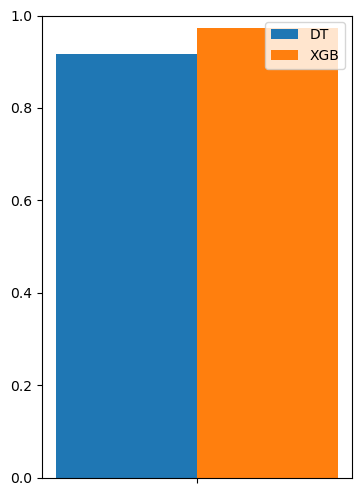

In [31]:
''' 코드를 작성해주세요 '''

print("\n======== DT 성능 확인 ========")
print(f"DT accuracy : {dt_accuracy}")
print(classification_report(y_test, y_pred_dt))

print("\n======== XGB 성능 확인 ========")
print(f"XGB accuracy : {xgb_accuracy}")
print(classification_report(y_test, y_pred_xgb))

accuracies = [dt_accuracy, xgb_accuracy]
model_names = ['DT', 'XGB']
x_pos = np.array([0])

plt.figure(figsize=(4, 6))

plt.bar(x_pos - 0.15, [dt_accuracy], width=0.3, label='DT')
plt.bar(x_pos + 0.15, [xgb_accuracy], width=0.3, label='XGB')

# x축 레이블 설정
plt.xticks([0], [''])

plt.ylim(0.0, 1.0) 
plt.legend()
plt.show()